In [1]:
import sys
import os
import numpy as np
import time
import random
import pathlib

import torch
from torch import nn

from utils.metrics import iou_score

from segmentation_models_pytorch import Unet
import cv2
import matplotlib.pyplot as plt
from utils import processing
import docdetect

import shutil

c:\Users\ADMIN\anaconda3\envs\card_classification\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
IMAGE_SIZE = (256, 256)
COLOR_MAP = 'gray'

SEED = 50

CHECKPOINT_PATH = pathlib.Path("./pretrained/model_checkpoint.pt")
FINAL_PATH = pathlib.Path("./pretrained/model_final.pt")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
MODEL_FILE = "pretrained/model_final.pt"

In [4]:
model = Unet(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
)
model = model.to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    [
        {"params": model.encoder.parameters(), "lr":1e-7},
        {"params": model.decoder.parameters(), "lr":1e-4},
    ],
    lr=1e-4,
)

In [5]:
checkpoint = torch.load(CHECKPOINT_PATH)
model.load_state_dict(checkpoint['model_state_dict'])
model.to(device)
model.eval()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_17400\2143768577.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(CHECKPOINT_PATH)


Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
      

In [6]:
TEST_PATH = "test"
TEST_FILE = "sample" 

In [7]:
def predict_image(model, image):
    with torch.no_grad():
        output = model(image.to(device))

    output = output.detach().cpu().numpy()[0]
    output = output.transpose((1, 2, 0))
    output = np.uint8(output)
    _, output = cv2.threshold(output, 127, 255, cv2.THRESH_BINARY_INV)

    return output

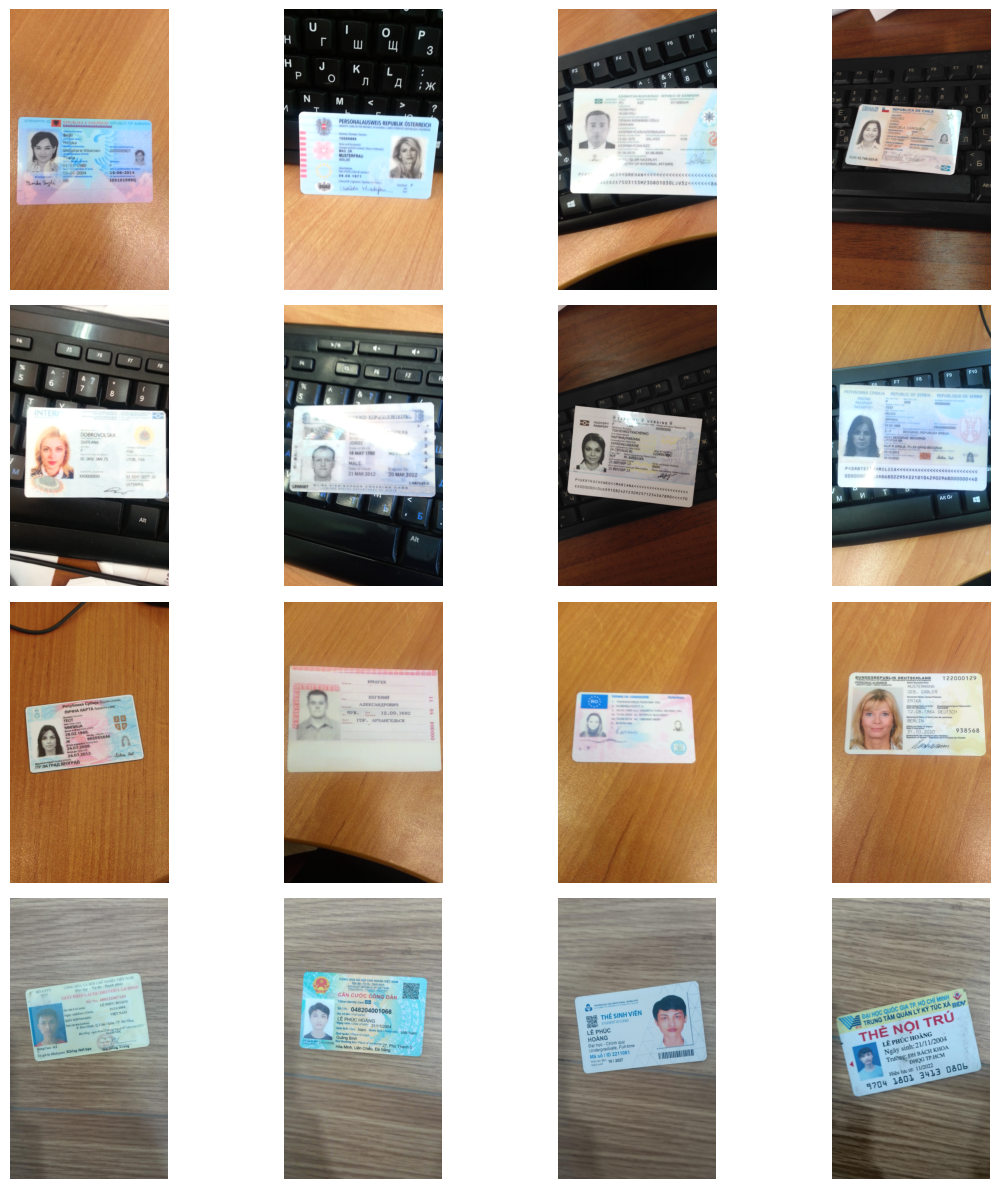

In [8]:
IMAGE = []
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for i in range(1, 17):
    input_dir = TEST_PATH + "/" + TEST_FILE + str(i) + ".png"
    img = cv2.imread(input_dir)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[(i-1)//4, (i-1)%4].imshow(img, cmap='gray', vmin=0, vmax=255)
    axes[(i-1)//4, (i-1)%4].axis('off')
    IMAGE.append(img)

plt.tight_layout()
plt.axis('off')
plt.show()

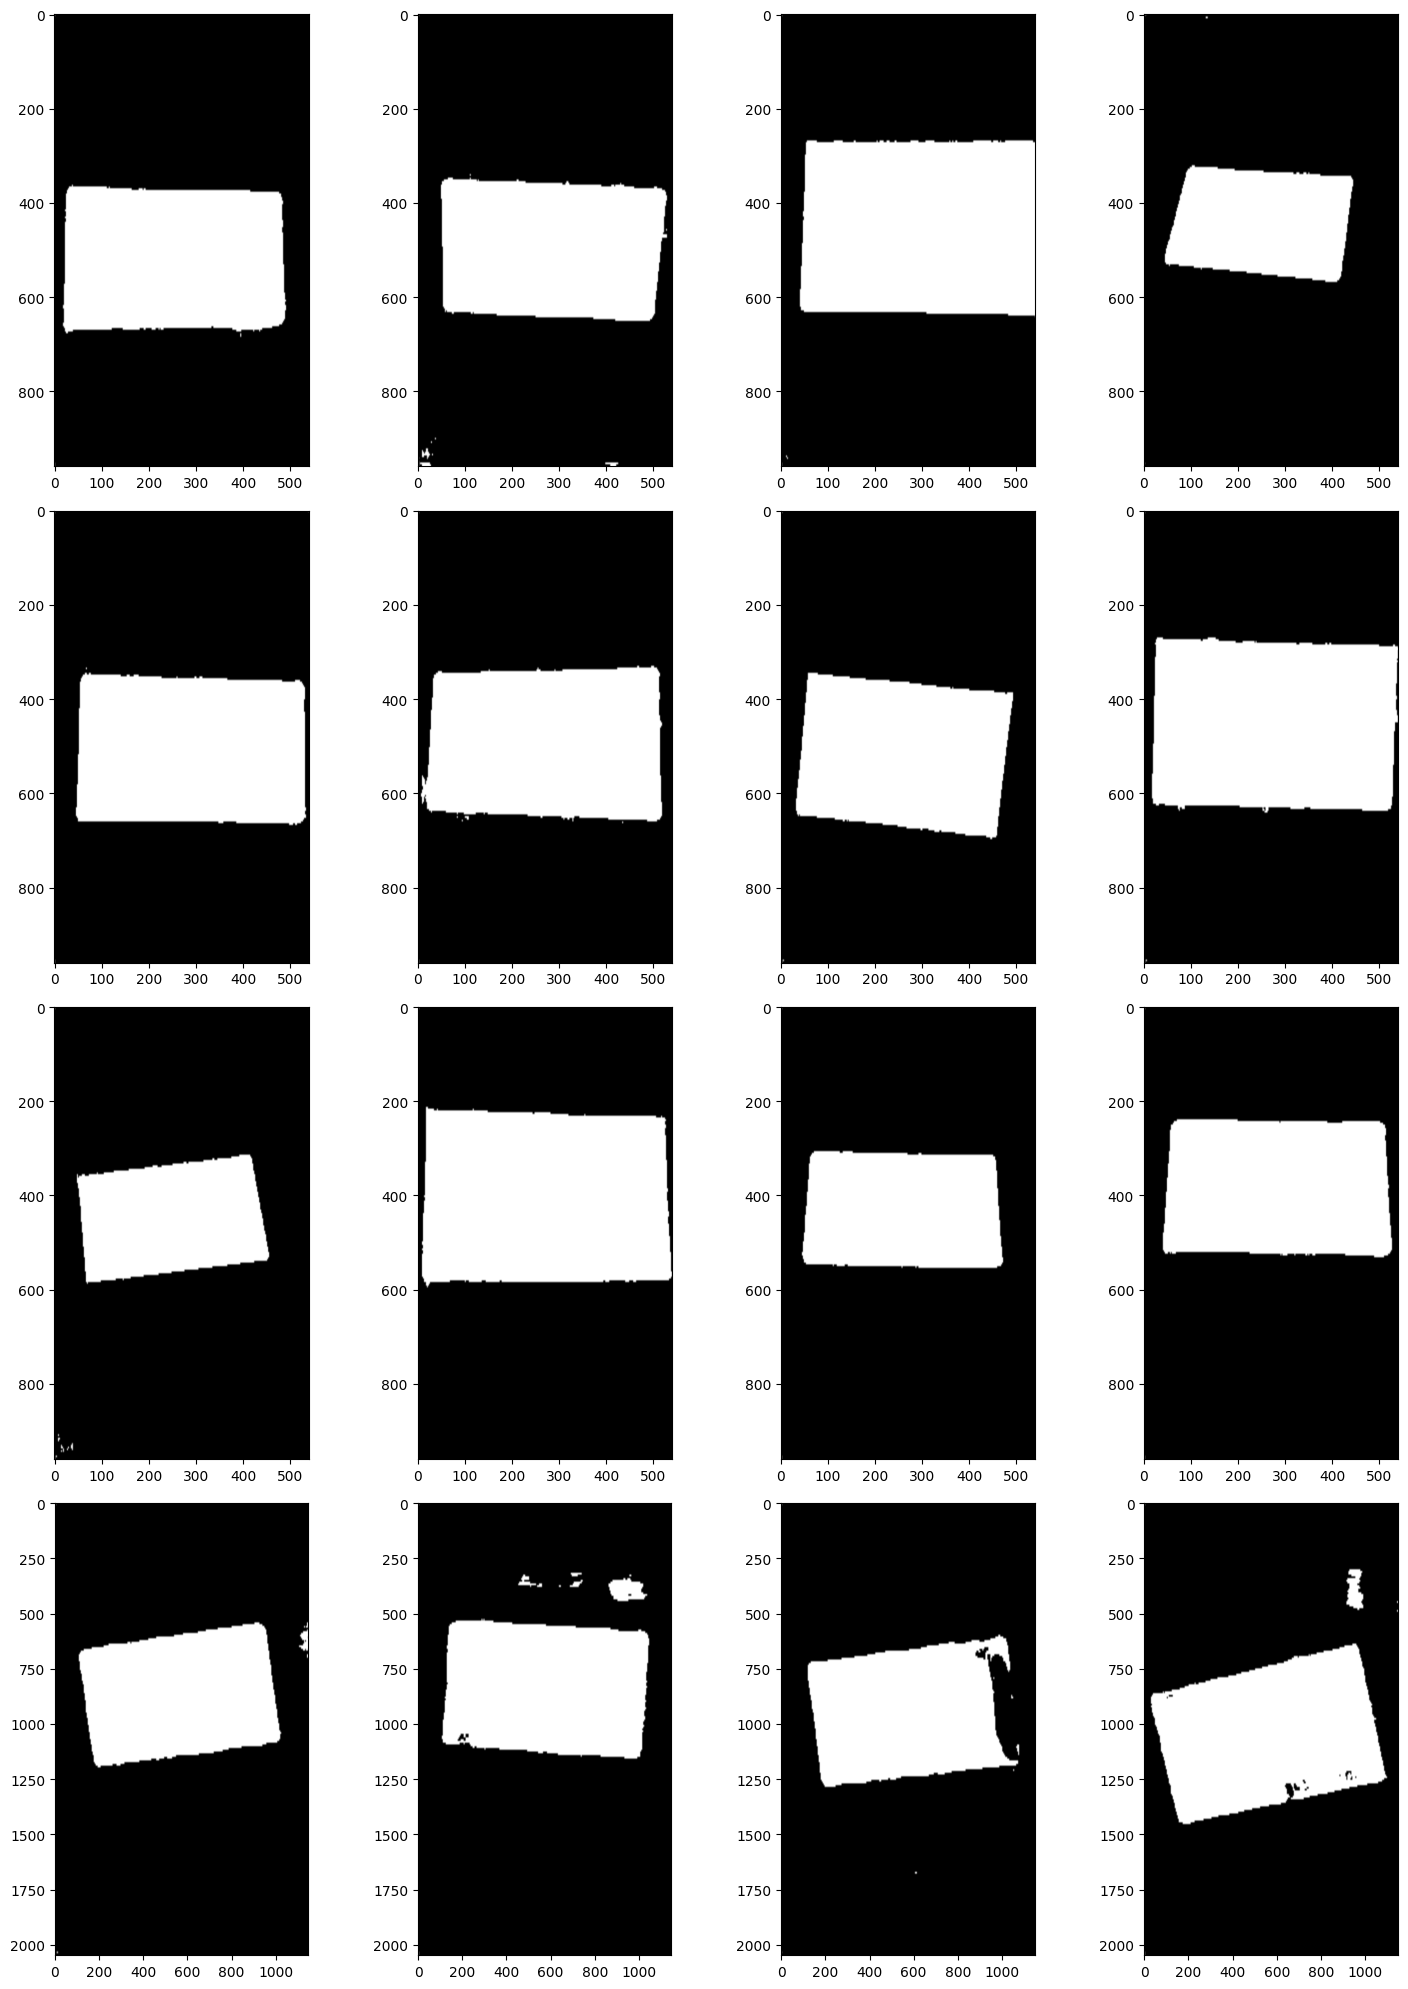

In [9]:
mask = []

fig, axes = plt.subplots(4, 4, figsize=(15, 20))
for i in range(1, 17):
    INPUT_FILE = TEST_PATH + "/" + TEST_FILE + str(i) + ".png"
    img, w, h = processing.load_image(INPUT_FILE)
    output = predict_image(model, img)
    mask_image = cv2.resize(output, (w, h))
    axes[(i-1)//4, (i-1)%4].imshow(mask_image, cmap='gray', vmin=0, vmax=255)
    mask.append(mask_image)
    
plt.tight_layout()
plt.show()

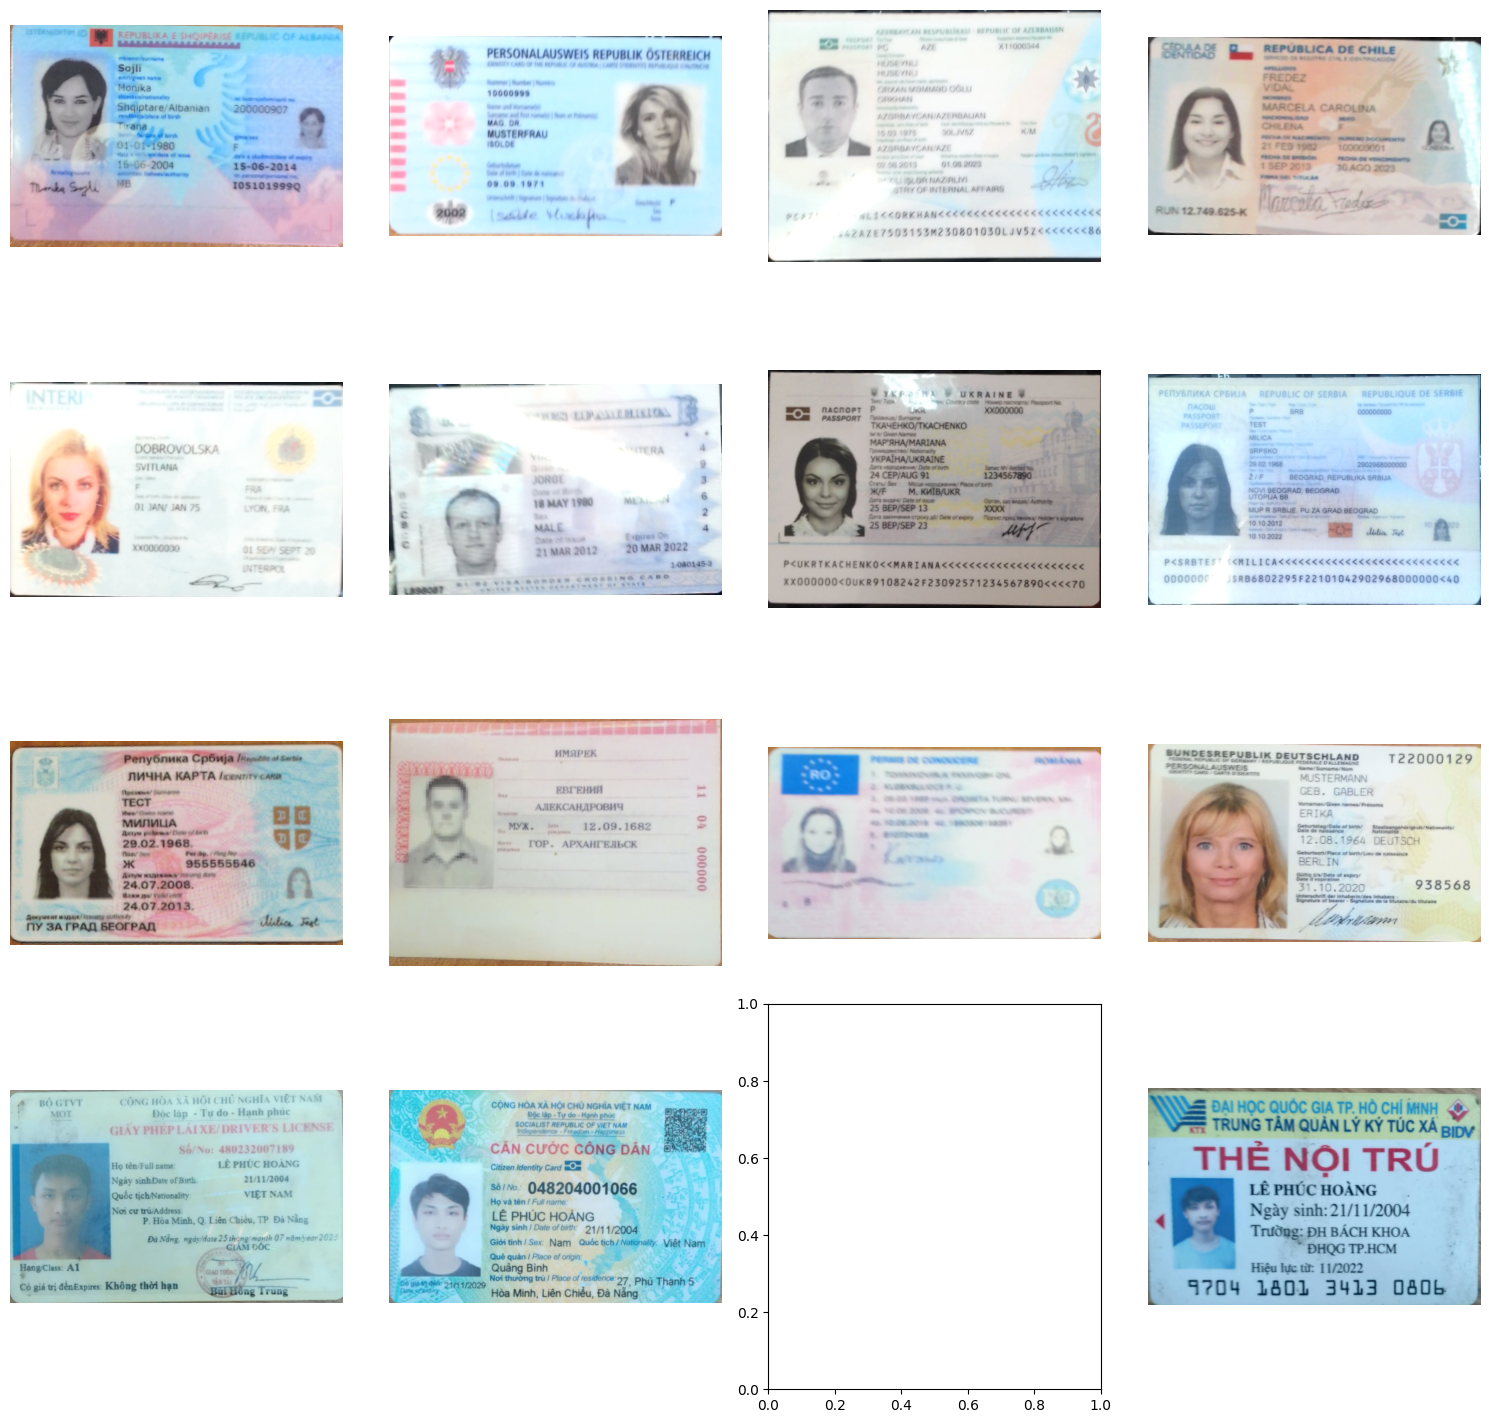

In [10]:
fig, axes = plt.subplots(4, 4, figsize=(15, 15))

for i in range(16):
    mask_image = mask[i]
    raw_image  = IMAGE[i]

    warped = processing.extract_idcard(raw_image, mask_image)
    if warped is not None:
        warped = cv2.cvtColor(warped, cv2.COLOR_BGR2RGB)
        axes[i//4, i%4].imshow(warped)
        axes[i//4, i%4].axis('off')

plt.tight_layout()
plt.show()

In [11]:
def extract_card(image, corners):
    if len(corners) < 4:
        return None
    corners = np.int32(corners)
    ordered_corners = processing.order_points(corners)
    return processing.four_point_transform(image, ordered_corners)

In [12]:
def auto_canny(image, sigma=0.33):
    # compute the median of the single channel pixel intensities
    v = np.median(image)

    # apply automatic Canny edge detection using the computed median
    lower = int(max(0, (1.0 - sigma) * v))
    upper = int(min(255, (1.0 + sigma) * v))
    edged = cv2.Canny(image, lower, upper, L2gradient = True)

    # return the edged image
    return edged

In [13]:
def document_detect(cropped_image):
    try:
        im = cv2.bitwise_not(cropped_image)
        saturation = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)
        saturation = cv2.medianBlur(saturation, 15)
        edges = auto_canny(saturation)
        lines = cv2.HoughLines(edges, 1, np.pi/180, 100)
        lines = lines[:, 0, :]
        lines = [(line[0], line[1]) for line in lines]
        line_groups = []
        for line in lines:
            if np.pi/6 < line[1] < np.pi/3 or np.pi*2/3 < line[1] < np.pi*5/6:
                continue
            if line[1] > np.pi*5/6:
                line = (-line[0], line[1] - np.pi)
            for group in line_groups:
                mean_rho = np.mean([line[0] for line in group])
                mean_theta = np.mean([line[1] for line in group])
                if abs(line[0] - mean_rho) < 50 and abs(line[1] - mean_theta) < 0.3:
                    group.append(line)
                    break
            else:
                line_groups.append([line])
                
        new_lines = []
        for group in line_groups:
            rho = np.mean([line[0] for line in group])
            theta = np.mean([line[1] for line in group])
            new_lines.append((rho, theta))
                
        lines = new_lines
        intersection = docdetect.find_intersections(lines, cropped_image)
        corners = [corner['coords'] for corner in intersection]
        card = extract_card(cropped_image, corners)
    # quadrilaterals = docdetect.find_quadrilaterals(intersection)
    # frame = docdetect.draw(quadrilaterals, cropped_image)
    # return frame
    except:
        return None
    return card

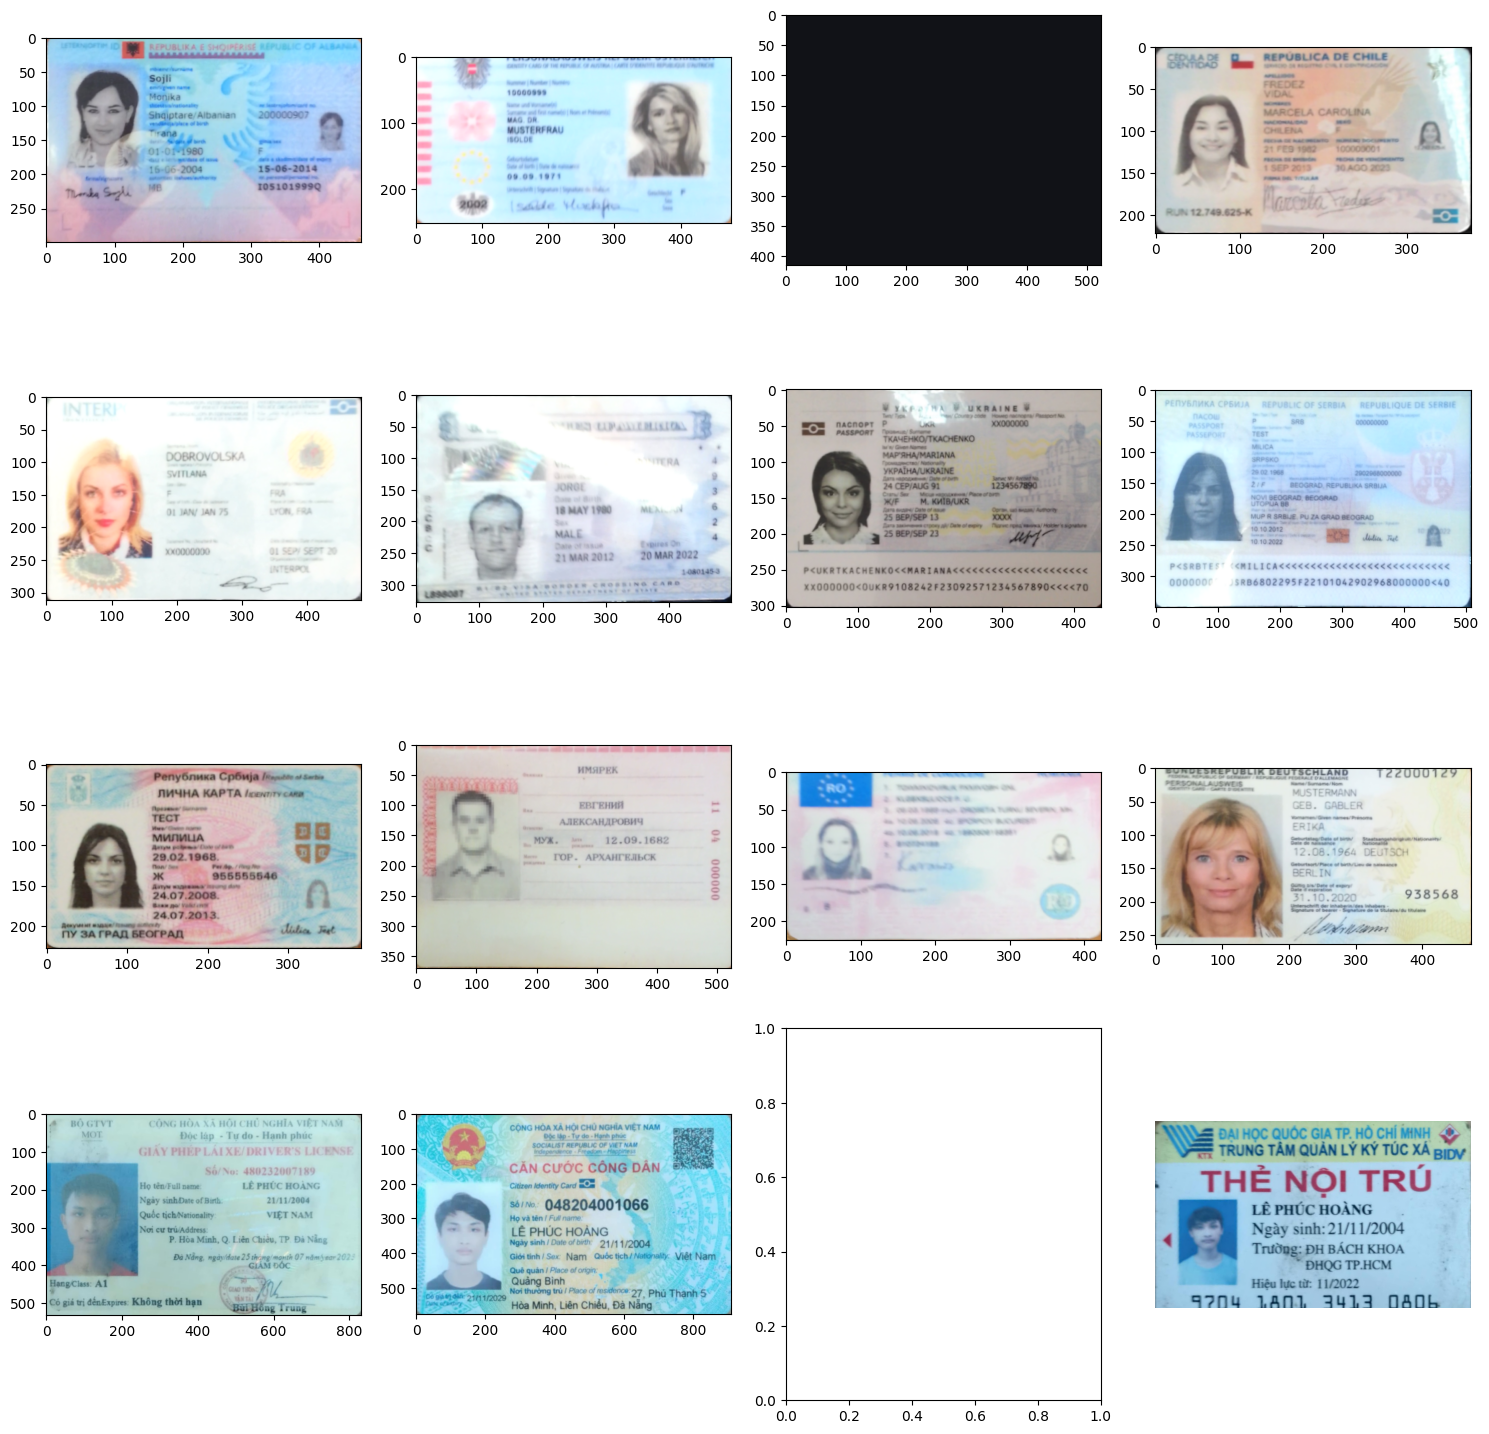

In [14]:
fig, axes = plt.subplots(4, 4, figsize=(15, 15))

for i in range(16):
    mask_image = mask[i]
    raw_image  = IMAGE[i]

    warped = processing.extract_idcard(raw_image, mask_image)
    if warped is not None:
        warped = cv2.cvtColor(warped, cv2.COLOR_BGR2RGB)
        cropped = processing.crop_image(raw_image, mask_image, expand_rate=0.1)
        card = document_detect(cropped)
        if card is not None:
            axes[i//4, i%4].imshow(card)

plt.axis('off')
plt.tight_layout()
plt.show()

In [15]:
image_dirs = "C:/Dataset/MIDV2020/dataset/photo/images"

In [16]:
total = 0
segmentation_fail = 0
card_fail = 0

In [17]:
output_dir = "output/"

In [18]:
for filename in os.listdir(output_dir):
    file_path = os.path.join(output_dir, filename)
    try:
        if os.path.isfile(file_path) or os.path.islink(file_path):
            os.unlink(file_path)
        elif os.path.isdir(file_path):
            shutil.rmtree(file_path)
    except Exception as e:
        print('Failed to delete %s. Reason: %s' % (file_path, e))


In [19]:
for image_type in os.listdir(image_dirs):
    output_image_type = output_dir + '/' + image_type
    os.mkdir(output_image_type)
    mask_dir = output_image_type + '/mask/'
    warped_dir = output_image_type + '/warped/'
    card_dir = output_image_type + '/card/'
    os.mkdir(mask_dir)
    os.mkdir(warped_dir)
    os.mkdir(card_dir)

    image_dir = image_dirs + '/' + image_type
    for img_name in os.listdir(image_dir):
        total += 1
        input, w, h = processing.load_image(image_dir + '/' + img_name)
        raw_image = cv2.imread(image_dir + '/' + img_name)
        raw_image = cv2.cvtColor(raw_image, cv2.COLOR_BGR2RGB)
        mask = predict_image(model, input)
        mask = cv2.resize(mask, (w, h))
        cv2.imwrite(mask_dir + img_name, mask)
        warped = processing.extract_idcard(raw_image, mask)
        if warped is not None:
            # warped = cv2.cvtColor(warped, cv2.COLOR_BGR2RGB)
            cv2.imwrite(warped_dir + img_name, warped)
            cropped = processing.crop_image(raw_image, mask, expand_rate=0.15)
            card = document_detect(cropped)
            if card is not None:
                card = cv2.cvtColor(card, cv2.COLOR_BGR2RGB)
                cv2.imwrite(card_dir + img_name, card)
            else:
                card_fail += 1
        else:
            segmentation_fail += 1


In [20]:
card_fail / total

0.055

In [21]:
segmentation_fail / total

0.626

In [22]:
image_dir = "C:/Dataset/card/datasets/train/train/images"
total = 0
segmentation_fail = 0
card_fail = 0
output_dir = "../data/output"

In [23]:
mask_dir = output_dir + '/mask/'
warped_dir = output_dir + '/warped/'
card_dir = output_dir + '/card/'

for img_name in os.listdir(image_dir):
    total += 1
    input, w, h = processing.load_image(image_dir + '/' + img_name)
    raw_image = cv2.imread(image_dir + '/' + img_name)
    raw_image = cv2.cvtColor(raw_image, cv2.COLOR_BGR2RGB)
    mask = predict_image(model, input)
    mask = cv2.resize(mask, (w, h))
    cv2.imwrite(mask_dir + img_name, mask)
    warped = processing.extract_idcard(raw_image, mask)
    if warped is not None:
        # warped = cv2.cvtColor(warped, cv2.COLOR_BGR2RGB)
        cv2.imwrite(warped_dir + img_name, warped)
        cropped = processing.crop_image(raw_image, mask, expand_rate=0.15)
        card = document_detect(cropped)
        if card is not None:
            card = cv2.cvtColor(card, cv2.COLOR_BGR2RGB)
            cv2.imwrite(card_dir + img_name, card)
        else:
            card_fail += 1
    else:
        segmentation_fail += 1

In [32]:
card_fail / total

0.16354166666666667

In [33]:
segmentation_fail / total

0.013541666666666667

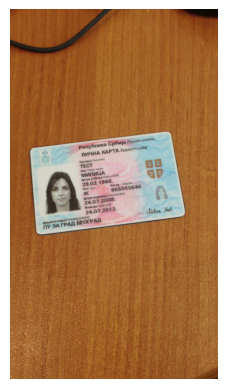

In [24]:
img_dir = "test/sample9.png"
input, w, h = processing.load_image(img_dir)
raw_image = cv2.imread(img_dir)
raw_image = cv2.cvtColor(raw_image, cv2.COLOR_BGR2RGB)
plt.axis('off')
plt.imshow(raw_image)

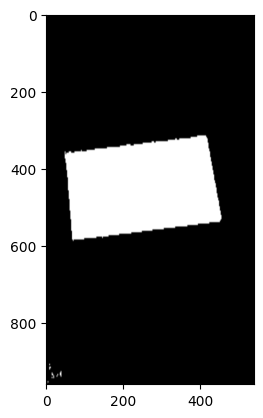

In [25]:
mask = predict_image(model, input)
mask = cv2.resize(mask, (w, h))
plt.imshow(mask, cmap='gray', vmin=0, vmax=255)

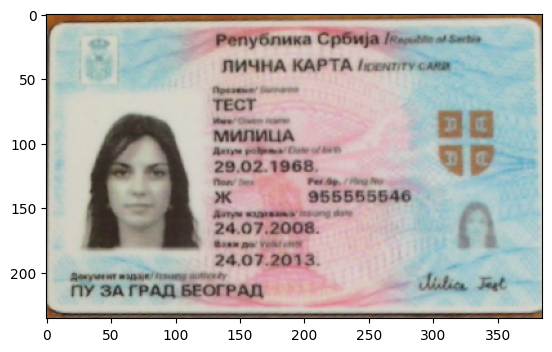

In [26]:
warped = processing.extract_idcard(raw_image, mask)
warped = cv2.cvtColor(warped, cv2.COLOR_BGR2RGB)
plt.imshow(warped)

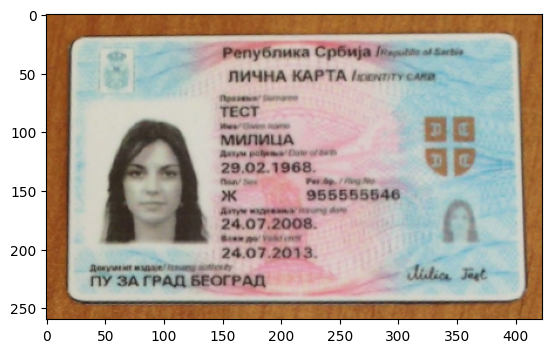

In [27]:
cropped = processing.crop_image(raw_image, mask, expand_rate=0.1)
plt.imshow(cropped)

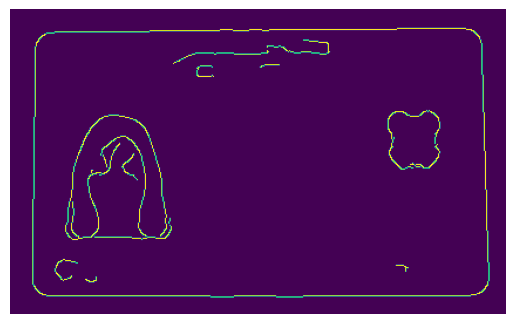

In [28]:
im = cv2.bitwise_not(cropped)
saturation = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)
saturation = cv2.medianBlur(saturation, 15)
edges = auto_canny(saturation, sigma=0.33)
plt.axis('off')
plt.imshow(edges)

In [29]:
lines = cv2.HoughLines(edges, 1, np.pi/180, 100)
lines = lines[:, 0, :]
lines = [(line[0], line[1]) for line in lines]
line_num = len(lines)
# new_lines = []
# for i in range(0, line_num):
#     valid = True
#     if np.pi/6 < lines[i][1] < np.pi/3 or np.pi*2/3 < lines[i][1] < np.pi*5/6:
#         continue
#     for line in new_lines:
#         if abs(line[0] - lines[i][0]) < 100 and abs(line[1] - lines[i][1]) < 0.3:
#             valid = False
#             break

line_groups = []
for line in lines:
    if np.pi/6 < line[1] < np.pi/3 or np.pi*2/3 < line[1] < np.pi*5/6:
        continue
    if line[1] > np.pi*5/6:
        line = (-line[0], line[1] - np.pi)
    for group in line_groups:
        mean_rho = np.mean([line[0] for line in group])
        mean_theta = np.mean([line[1] for line in group])
        if abs(line[0] - mean_rho) < 50 and abs(line[1] - mean_theta) < 0.3:
            group.append(line)
            break
    else:
        line_groups.append([line])
        
new_lines = []
for group in line_groups:
    rho = np.mean([line[0] for line in group])
    theta = np.mean([line[1] for line in group])
    new_lines.append((rho, theta))

        
lines = new_lines
print(lines)

[(244.0, 1.5707964), (400.0, -0.03490653832490054), (22.0, 0.017453292), (19.0, 1.5620697)]


(244.0, 1.5707964)
(400.0, -0.03490653832490054)
(22.0, 0.017453292)
(19.0, 1.5620697)


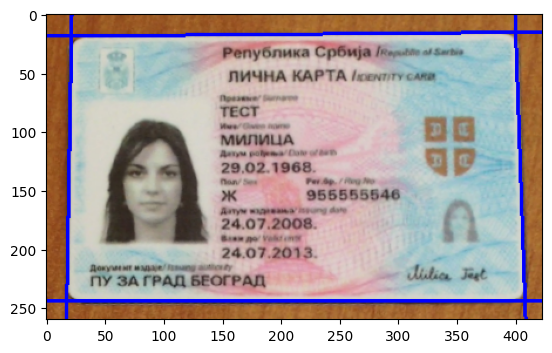

In [30]:
tmp = cropped.copy()
for line in lines:
    print(line)
    rho,theta = line
    a = np.cos(theta)
    b = np.sin(theta)
    x0 = a*rho
    y0 = b*rho
    x1 = int(x0 + 1000*(-b))
    y1 = int(y0 + 1000*(a))
    x2 = int(x0 - 1000*(-b))
    y2 = int(y0 - 1000*(a))

    cv2.line(tmp, (x1, y1), (x2, y2), (0,0,255), 2)

plt.imshow(tmp)

[(409, 244), (18, 244), (401, 16), (22, 19)]


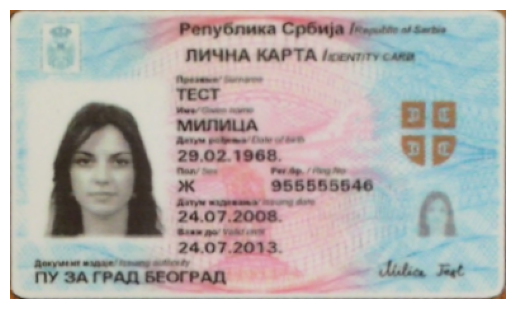

In [31]:
intersection = docdetect.find_intersections(lines, im)
corners = [corner['coords'] for corner in intersection]
print(corners)
card = extract_card(cropped, corners)
plt.axis('off')
plt.imshow(card)